In [1]:
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from tqdm.notebook import tqdm

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import  Dataset, DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", torch.cuda.get_device_name(0))

rng = np.random.default_rng()

Using device: NVIDIA GeForce RTX 2080


In [2]:
# Download CIFAR10 from PyTorch
train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True)

classes = train.classes # Labels

training_samples = train.data # (50000, 32, 32, 3)
training_labels = train.targets

testing_samples = test.data # (10000, 32, 32, 3)
testing_labels = test.targets 

In [3]:
TRAINING_SAMPLES_USED = 50000

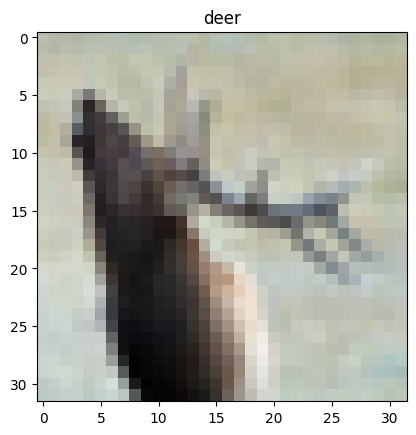

In [4]:
# Visualize random training data
sample_idx = np.random.randint(0, TRAINING_SAMPLES_USED)

plt.imshow(training_samples[sample_idx])
plt.title(classes[training_labels[sample_idx]])
plt.show()

In [5]:
# Data Preperation
X_train = (training_samples[:TRAINING_SAMPLES_USED] / 127.5) - 1.0
X_train = np.transpose(X_train, (0, 3, 1, 2)) # (50,000, 3, 32, 32)
Y_train = np.array(training_labels) # (50,000, 1)

X_test = (testing_samples / 127.5) - 1.0
X_test = np.transpose(X_test, (0, 3, 1, 2)) # (10,000, 3, 32, 32)
Y_test = np.array(testing_labels) # (10,000, 1)

In [6]:
# Setting up noise schedule 
T = 1000

var_decay_min = 0.0001
var_decay_max = 0.02

beta = np.linspace(var_decay_min, var_decay_max, T)
alpha = (1 - beta)

alpha_bar = np.cumprod(alpha)

mean_scale = np.sqrt(alpha_bar)
var_scale = np.sqrt(1-alpha_bar)

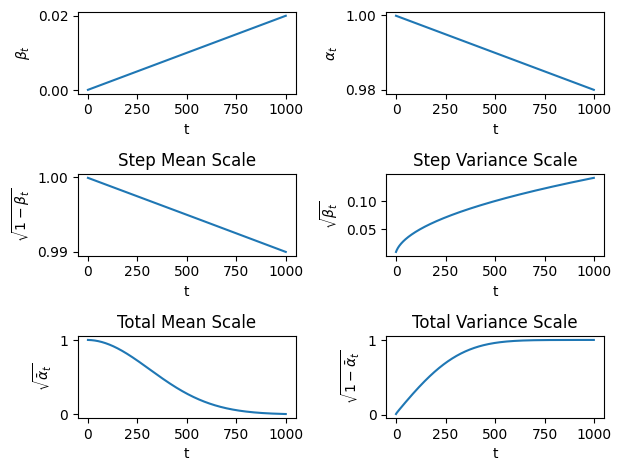

In [7]:
fig, axs = plt.subplots(3, 2)

axs[0, 0].plot(beta)
axs[0, 0].set_ylabel(r'$\beta_t$')
axs[0, 0].set_xlabel('t')

axs[0, 1].plot(1-beta)
axs[0, 1].set_ylabel(r'$ \alpha_t $')
axs[0, 1].set_xlabel('t')

axs[1, 0].plot(np.sqrt(1-beta))
axs[1, 0].set_ylabel(r'$ \sqrt{1-\beta_t} $')
axs[1, 0].set_xlabel('t')
axs[1, 0].set_title('Step Mean Scale')

axs[1, 1].plot(np.sqrt(beta))
axs[1, 1].set_ylabel(r'$ \sqrt{\beta_t} $')
axs[1, 1].set_xlabel('t')
axs[1, 1].set_title('Step Variance Scale')

axs[2, 0].plot(np.sqrt(alpha_bar))
axs[2, 0].set_ylabel(r'$ \sqrt{\bar \alpha_t} $')
axs[2, 0].set_xlabel('t')
axs[2, 0].set_title('Total Mean Scale')

axs[2, 1].plot(np.sqrt(1-alpha_bar))
axs[2, 1].set_ylabel(r'$ \sqrt{1 - \bar \alpha_t} $')
axs[2, 1].set_xlabel('t')
axs[2, 1].set_title('Total Variance Scale')

plt.tight_layout()
plt.show()
plt.close()

In [8]:
def diffuse(x0, t, mean_scale, var_scale):
    if t==0:
        return x0
    return x0 * mean_scale[t-1] + var_scale[t-1]*rng.normal(0, 1, size=x0.shape)

def diffusion_step(x, t, beta):
    if t==0:
        return x
    return x* np.sqrt(1-beta[t-1]) + np.sqrt(beta[t-1])*rng.normal(0, 1, size=x.shape)

def data_to_image(x):
    if x.ndim == 4:
        x = np.transpose(x, (0, 2, 3, 1))
    elif x.ndim == 3:
        x = np.transpose(x, (1, 2, 0))
    else:
        raise ValueError("Input must be (N,C,H,W) or (C,H,W)")
        
    return np.clip((x+1.0)*127.5, 0.0, 255.0).astype(np.uint8)

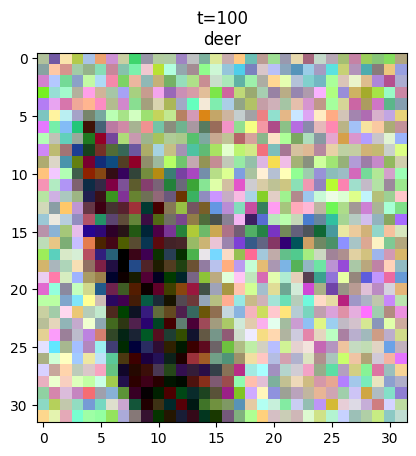

In [9]:
t=100

x_t = diffuse(X_train[sample_idx], t, mean_scale, var_scale)

plt.imshow(data_to_image(x_t))
plt.title('t='+str(t)+ '\n' + classes[training_labels[sample_idx]])
plt.show()
plt.close()

In [10]:
spacing = 10

x_t = X_train[sample_idx]

fig, ax = plt.subplots()

im = ax.imshow(data_to_image(x_t))

def update(frame):
    global x_t
    if frame==0:
        im.set_data(data_to_image(x_t))
    else:
        for i in range(spacing):
            t = ((frame*spacing)-spacing) + i + 1
            x_t = diffusion_step(x_t, t, beta)
        im.set_data(data_to_image(x_t))
        
    ax.set_title('t='+ str(frame*spacing)+ '\n' + classes[training_labels[sample_idx]])
    return im

ani = animation.FuncAnimation(fig=fig, func=update, frames=int(T/spacing)+1, interval=30)

plt.close()
HTML(ani.to_jshtml())

In [11]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_dim=512, norm_groups=32):
        super().__init__()
        # Notes:
        # BOTH in_channels and out_channels must be divisible by norm_groups
    
        self.norm1 = nn.GroupNorm(norm_groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=1, padding=1)
    
        self.norm2 = nn.GroupNorm(norm_groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1)
    
        self.shortcut_conv = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, 
                                                                                         out_channels, 
                                                                                         1, 
                                                                                         stride=1, 
                                                                                         padding=0)
    
          
        self.act = nn.SiLU()
    
        self.proj_t = nn.Linear(t_dim, out_channels)

    
    def forward(self, x, t):
        h = x
        h = self.norm1(h)
        h = self.act(h)
        h = self.conv1(h)

        h = h + self.proj_t(self.act(t))[:, :, None, None]

        h = self.norm2(h)
        h = self.act(h)
        h = self.conv2(h)

        x = self.shortcut_conv(x)

        return x + h

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Notes:
        # Kernel does not "fit". Result is equivalent to manually asymmetrically padding the top and left edges 

        self.conv = nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1)

    def forward(self, x):
        x = self.conv(x)
        return x

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv = nn.Conv2d(in_channels, out_channels, 3, stride=1, padding=1)
        
    def forward(self, x):
        x = self.up(x)
        x = self.conv(x)
        return x

class Attention(nn.Module):
    def __init__(self, embed_dim, num_heads, norm_groups=32):
        super().__init__()
        # Note:
        # embed_dim is equivalent to the number of input channels & will also be the number of output channels
        # Must be BOTH divisible by norm_groups and num_heads

        self.attend = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True, bias=True)
        self.norm = nn.GroupNorm(norm_groups, embed_dim)
        
    def forward(self, x):
        B, C, H, W = x.shape

        h = self.norm(x)
        tokens = h.flatten(2, 3).transpose(1,2)

        attention = self.attend(tokens, tokens, tokens, need_weights=False)[0]   

        attention = attention.transpose(1,2).reshape(B, C, H, W)

        return x + attention
    

class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.y_embedding = nn.Embedding(11, 256)

        self.y_mlp = nn.Sequential(
            nn.Linear(256, 512),
            nn.SiLU(),
            nn.Linear(512, 512)
        )

        self.t_mlp = nn.Sequential(
            nn.Linear(256, 512),
            nn.SiLU(),
            nn.Linear(512, 512)
        )
        
        # (N, 3, 32, 32)
        self.input_conv = nn.Conv2d(3, 64, 3, stride=1, padding=1)
        # (N, 64, 32, 32)
        self.res1 = nn.ModuleList([
            ResBlock(64, 64),
            ResBlock(64, 64)
        ])
        # (N, 64, 32, 32) --> x1
        self.down1 = Down(64, 64)
        # (N, 64, 16, 16)
        self.res2 = nn.ModuleList([
            ResBlock(64, 128),
            ResBlock(128, 128)
        ])
        # (N, 128, 16, 16)
        self.attn1 = Attention(128, 4)
        # (N, 128, 16, 16) --> x2
        self.down2 = Down(128, 128)
        # (N, 128, 8, 8)
        self.res3 = nn.ModuleList([
            ResBlock(128, 256),
            ResBlock(256, 256)
        ])
        # (N, 256, 8, 8)
        self.attn2 = Attention(256, 8)
        # (N, 256, 8, 8) --> x3
        self.down3 = Down(256, 256)
        # (N, 256, 4, 4)
        self.bottle = nn.ModuleList([
            ResBlock(256, 512),
            ResBlock(512, 512)
        ])
        # (N, 512, 4, 4)
        self.attn3 = Attention(512, 16)
        # (N, 512, 4, 4)
        self.up1 = Up(512, 512)
        # (N, 512, 8, 8) 
        #        +x3
        # (N, 768, 8, 8)
        self.res4 = nn.ModuleList([
            ResBlock(768, 256),
            ResBlock(256, 256)
        ])
        # (N, 256, 8, 8)
        self.up2 = Up(256, 256)
        # (N, 256, 16, 16) 
        #        +x2
        # (N, 384, 16, 16)
        self.res5 = nn.ModuleList([
            ResBlock(384, 128),
            ResBlock(128, 128)
        ])
        # (N, 128, 16, 16)
        self.up3 = Up(128, 128)
        # (N, 128, 32, 32)
        #        +x1
        # (N, 192, 32, 32)
        self.res6 = nn.ModuleList([
            ResBlock(192, 64),
            ResBlock(64, 64)
        ]) 
        # (N, 64, 32, 32)
        self.out_conv = nn.Sequential(
            nn.GroupNorm(32, 64),
            nn.SiLU(),
            nn.Conv2d(64, 3, 3, stride=1, padding=1)
        )
        # (N, 3, 32, 32)
        
    def forward(self, x, t, y):
        t = self.get_time_embedding_vector(t, 256)
        t = self.t_mlp(t)

        y = self.y_embedding(y)
        y = self.y_mlp(y)

        t = t + y

        x = self.input_conv(x)
        for block in self.res1:
            x = block(x, t)
        x1 = x
        x = self.down1(x)
        for block in self.res2:
            x = block(x, t)
        x = self.attn1(x)
        x2 = x
        x = self.down2(x)
        for block in self.res3:
            x = block(x, t)
        x = self.attn2(x)
        x3 = x
        x = self.down3(x)
        for block in self.bottle:
            x = block(x, t)
        x = self.attn3(x)
        x = self.up1(x)
        x = torch.cat([x, x3], dim=1)
        for block in self.res4:
            x = block(x, t)
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        for block in self.res5:
            x = block(x, t)
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        for block in self.res6:
            x = block(x, t)
        x = self.out_conv(x)
        return x

    def get_time_embedding_vector(self, t, embedding_dim):
        t = torch.atleast_1d(t)
        half_dim = embedding_dim//2
        
        freqs = torch.arange(0, half_dim, dtype=torch.float32, device=device) * (math.log(10000) / (half_dim-1))
        freqs = torch.exp(-freqs)
        
        return torch.cat([torch.sin(t[:, None] * freqs[None, :]), torch.cos(t[:, None] * freqs[None, :]) ], dim=1)

In [12]:
def create_ema(model):
    ema = copy.deepcopy(model)
    for p in ema.parameters():
        p.requires_grad_(False)
    ema.eval()
    return ema

def update_ema(ema, model, decay):
    with torch.no_grad():
        for ema_p, p in zip(ema.parameters(), model.parameters()):
            ema_p.mul_(decay).add_(p.detach(), alpha=1-decay)

class CustomDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        return x, y

In [13]:
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).long()

mean_scale_tensor = torch.from_numpy(mean_scale).float()
var_scale_tensor = torch.from_numpy(var_scale).float()

dataset = CustomDataset(X_train_tensor, Y_train_tensor)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [14]:
def train(model, criterion, optimizer, dataloader, mean_scale_tensor, var_scale_tensor, p_null=0.1, ema_decay=0.99, epochs=1, save=False, model_name=""):
    training_loss = []

    ema = create_ema(model).to(device)
    
    model = model.to(device)
    mean_scale_tensor = mean_scale_tensor.to(device)
    var_scale_tensor = var_scale_tensor.to(device)

    num_steps = epochs * len(dataloader)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_steps)
    
    pbar = tqdm(range(epochs), desc="Training")
    for epoch in pbar:
        model.train()
        epoch_loss = 0.0
    
        for X_batch, Y_batch in dataloader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
    
            batch_size = X_batch.shape[0]
    
            t_batch = torch.randint(low=1, high=T+1, size=(batch_size,), device=device)     
    
            epsilon_batch = torch.randn_like(X_batch, device=device, dtype=torch.float32)

            X_t_batch = X_batch * mean_scale_tensor[t_batch-1][:, None, None, None] + var_scale_tensor[t_batch-1][:, None, None, None] * epsilon_batch

            p = torch.rand(size=(batch_size, ), device=device, dtype=torch.float32)

            null_label = torch.tensor(10, device=device, dtype=torch.long)
            
            Y_batch = torch.where(p > p_null, Y_batch, null_label)
            
            optimizer.zero_grad()
            
            epsilon_hat = model(X_t_batch, t_batch.float(), Y_batch)
    
            loss = criterion(epsilon_hat, epsilon_batch)
    
            loss.backward()
            optimizer.step()
            scheduler.step()

            update_ema(ema, model, ema_decay)
    
            epoch_loss += loss.item()

            
        training_loss.append(epoch_loss)
        pbar.set_postfix({"loss": f"{epoch_loss:.4f}"})

    if save:
        torch.save(model.state_dict(), "./Models/" + model_name + ".pth")
        torch.save(ema.state_dict(), "./Models/" + model_name + "_EMA.pth")

    return model, training_loss

Training:   0%|          | 0/1279 [00:00<?, ?it/s]

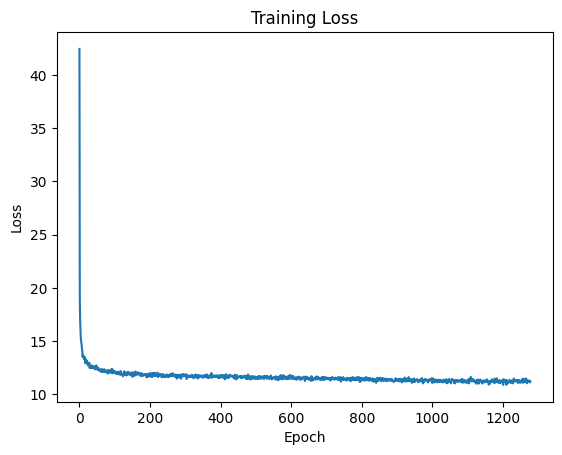

In [15]:
TRAIN_NEW_MODEL = True
SAVE_MODEL = True
MODEL_NAME = "CIFAR10_Model"
epochs = 1279
ema_decay = 0.9999

if TRAIN_NEW_MODEL:
    model = DiffusionModel()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
    model, training_loss = train(model, criterion, optimizer, dataloader, mean_scale_tensor, var_scale_tensor, ema_decay=ema_decay, epochs=epochs, save=SAVE_MODEL, model_name=MODEL_NAME)
    
    plt.plot(training_loss)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()
    plt.close()

In [16]:
def reverse_diffuse(model, beta, alpha, alpha_bar, samples=1, start=T, stop=1, X_T=None, label=10, w=2):
    model = model.to(device)
    beta = beta.to(device)
    alpha = alpha.to(device)
    alpha_bar = alpha_bar.to(device)

    model.eval()
    
    if X_T is None:
        X_T = torch.randn((samples, 3, 32, 32), device=device, dtype=torch.float32)
    else:
        samples = X_T.shape[0]

    X_t = X_T
    X_t = X_t.to(device)

    with torch.no_grad():
        for t in reversed(range(stop, start+1)):
            if t == 1:
                t_model = torch.full((samples,), t, device=device, dtype=torch.float32)
                y_model = torch.full((samples,), 10, device=device, dtype=torch.long)   
                epsilon_hat = model(X_t, t_model, y_model)
                if label != 10:
                    y_model = torch.full((samples,), label, device=device, dtype=torch.long)
                    epsilon_hat_conded = model(X_t, t_model, y_model)
                    epsilon_hat = epsilon_hat + w*(epsilon_hat_conded - epsilon_hat)
                mu_t = (1./torch.sqrt(alpha[t-1])) * (X_t - (beta[t-1]/torch.sqrt(1-alpha_bar[t-1]))*epsilon_hat)
                X_t = mu_t
            else:
                t_model = torch.full((samples,), t, device=device, dtype=torch.float32)
                y_model = torch.full((samples,), 10, device=device, dtype=torch.long)   
                epsilon_hat = model(X_t, t_model, y_model)
                if label != 10:
                    y_model = torch.full((samples,), label, device=device, dtype=torch.long)
                    epsilon_hat_conded = model(X_t, t_model, y_model)
                    epsilon_hat = epsilon_hat + w*(epsilon_hat_conded - epsilon_hat)
                epsilon = torch.randn_like(X_t, device=device, dtype=torch.float32)
                mu_t = (1./torch.sqrt(alpha[t-1])) * (X_t - (beta[t-1]/torch.sqrt(1-alpha_bar[t-1]))*epsilon_hat)
                beta_t = (1-alpha_bar[t-2]) / (1-alpha_bar[t-1]) * beta[t-1]
                X_t = mu_t + torch.sqrt(beta_t) * epsilon
    return X_t

In [53]:
model = DiffusionModel()
model.load_state_dict(torch.load("./Models/CIFAR10_Model_EMA.pth", weights_only=True))

beta_tensor = torch.from_numpy(beta).float()
alpha_tensor = torch.from_numpy(alpha).float()
alpha_bar_tensor = torch.from_numpy(alpha_bar).float()

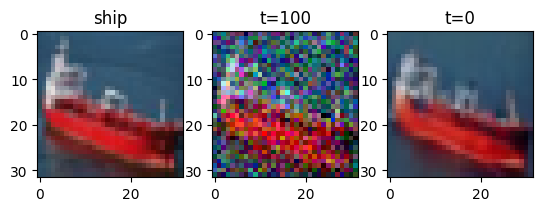

In [25]:
t_start = 100
t_stop = 1

test_sample_idx = np.random.randint(0, 10000)

x_test = diffuse(X_test[test_sample_idx], t_start, mean_scale, var_scale)
x_test_tensor = torch.from_numpy(np.array([x_test])).float()
X_rev = reverse_diffuse(model, beta_tensor, alpha_tensor, alpha_bar_tensor, X_T=x_test_tensor, start=t_start, stop=t_stop).cpu().numpy()

fig, axes = plt.subplots(nrows=1, ncols=3)

axes[0].imshow(data_to_image(X_test[test_sample_idx]))
axes[0].set_title(classes[testing_labels[test_sample_idx]])

axes[1].imshow(data_to_image(x_test))
axes[1].set_title("t="+str(t_start))

axes[2].imshow(data_to_image(X_rev[0]))
axes[2].set_title("t=0")

plt.show()
plt.close()

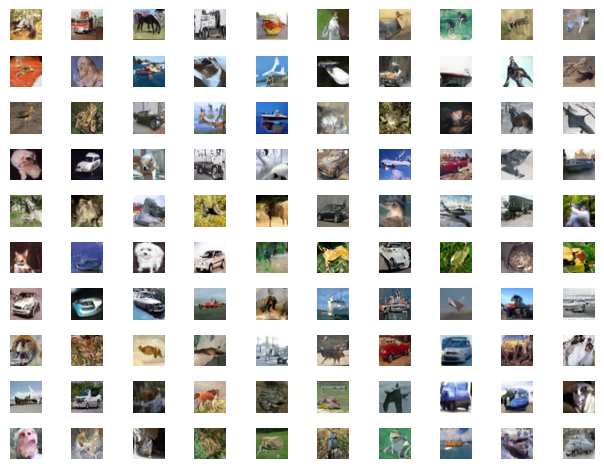

In [70]:
samples=100

X_rev = reverse_diffuse(model, beta_tensor, alpha_tensor, alpha_bar_tensor, samples=samples).cpu().numpy()

fig, axes = plt.subplots(nrows=int(np.sqrt(samples)), ncols=int(np.sqrt(samples)))

for i, ax in enumerate(axes.flat):
    ax.imshow(data_to_image(X_rev[i]))
    ax.axis('off')

plt.tight_layout()
plt.show()
plt.close()

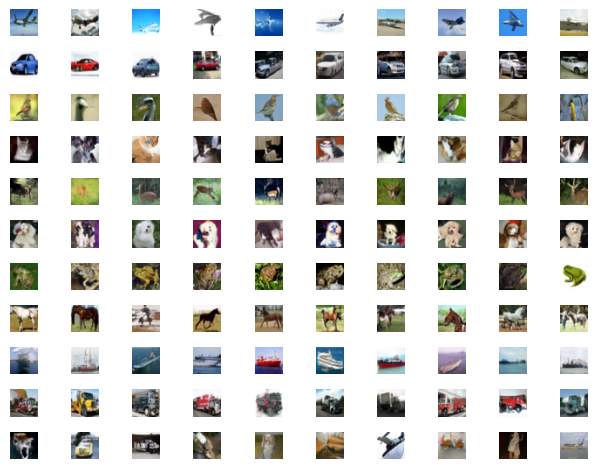

In [75]:
samples_per_class = 10
w=3

images = []
for i in range(11):
    X_rev = reverse_diffuse(model, beta_tensor, alpha_tensor, alpha_bar_tensor, samples=samples_per_class, label=i, w=w).cpu().numpy()
    for j in range(len(X_rev)):
        images.append(X_rev[j])

fig, axes = plt.subplots(nrows=11, ncols=samples_per_class)

for i, ax in enumerate(axes.flat):
    ax.imshow(data_to_image(images[i]))
    ax.axis('off')

plt.tight_layout()
plt.show()
plt.close()


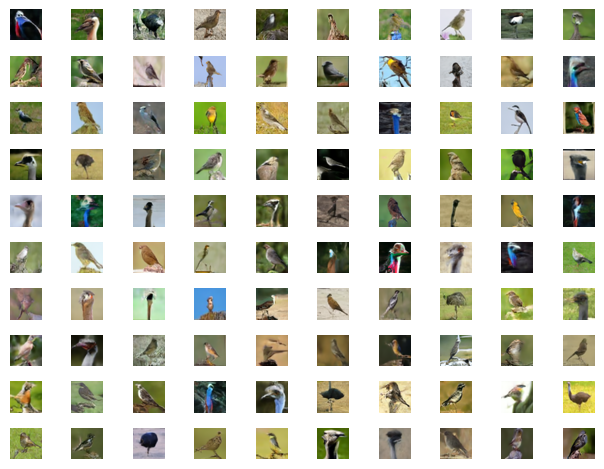

In [76]:
samples= 100
label = 2
w=3

X_rev = reverse_diffuse(model, beta_tensor, alpha_tensor, alpha_bar_tensor, samples=samples, label=label, w=w).cpu().numpy()

fig, axes = plt.subplots(nrows=int(np.sqrt(samples)), ncols=int(np.sqrt(samples)))

for i, ax in enumerate(axes.flat):
    ax.imshow(data_to_image(X_rev[i]))
    ax.axis('off')

plt.tight_layout()
plt.show()
plt.close()